# Supplementary Figure 3.2: Fixed-bound simulations

Can a **fixed-bound decision process** with **variable non-decision times (NDTs)**
and **sensory noise** reproduce the observed incongruence and premature-crossing rates
in OL blocks 1–3?

## Analysis assumption

`get_bounds` always assumes NDT = 2 (`DT = RT − 3`).  When the true NDT ≠ 2 or sensory
noise triggers a crossing of the *perceived* DV before the *true* DV has crossed the bound,
two artefacts arise:

- **Incongruence**: sign(midpoint) ≠ choice.  Caused by NDT_true > 2 (midpoint sampled in
  the post-crossing window) **or** by sensory noise (perceived-DV crossing when the true DV
  has not yet reached the bound).
- **Premature crossing**: the true crossing step precedes the assumed DT and exceeds the
  peak-step bound.  Caused **only** by NDT_true > 2.

## Generative model

GENERATIVE_STD = 0.15; per-subject GENERATIVE_MEAN ∝ median |SNR|.  The full real-data
pipeline (`get_bounds` → bias correction) is applied to simulation output identically to
the real data, so true and simulated trials are on the same scale.

## Four scenarios (2 × 2 factorial)

|  | σ = 0 (no sensory noise) | σ = best per block |
|---|---|---|
| **Fixed NDT = 2** | Baseline — neither mechanism active | NDT=2 + noise |
| **Best NDT distribution** | Best NDT, no noise | **Best full model** |

NDT family: `p(NDT=2) = 1 [mode], p(NDT=1) = p(NDT=3) = α, p(NDT=4) = β`.
Block 2 in the full model additionally uses NDT=5 (weight γ) — see *Synthesis* below.

Parameters for the three non-baseline scenarios were found by independent per-block grid
searches (see `run-sims` comments for search details):

**Fixed NDT=2, best noise** — 1-D σ sweep [0, 0.40] step 0.02, α=β=0:

| Block | σ |
|---|---|
| 1 | 0.12 |
| 2 | 0.14 |
| 3 | 0.16 |

**Best NDT, no noise** — 2-D α×β grid (α ∈ [0, 0.5], β ∈ [0, 0.9], step 0.1; σ = 0):

| Block | α | β |
|---|---|---|
| 1 | 0.4 | 0.8 |
| 2 | 0.0 | 0.9 |
| 3 | 0.5 | 0.9 |

**Best NDT + noise (full model)** — 3-parameter (α, β, σ) grid for B1 and B3;
4-parameter extended (α, β, γ, σ) search for B2:

| Block | α | β | γ (NDT=5) | σ |
|---|---|---|---|---|
| 1 | 0.3 | 0.5 | 0 | 0.10 |
| 2 | 0.4 | 0.3 | 1.0 | 0.10 |
| 3 | 0.5 | 0.9 | 0 | 0.02 |

## Synthesis

**Mechanism decomposition:**
- *frac_incong* requires sensory noise — NDT variability alone underestimates incongruence
  because post-crossing midpoints remain on the correct side of zero.
- *frac_early* requires NDT > 2 — noise has no effect on premature crossings, which
  depend only on the true DV path seen by `get_bounds`.

**Block 2 (coin-penalty condition)** was not adequately matched by the standard NDT ≤ 4
family: high β (NDT=4 weight) raises early but leaves incong too low; adding σ raises
incong but not early.  An extended achievability search (β ∈ [0, 2.0], γ ∈ {0, 0.5, 1.0}
for NDT=5, σ ∈ [0, 0.25]) revealed that the target (incong=0.077, early=0.181) is reachable
with α=0.4, β=0.3, γ=1.0, σ=0.10 → simulated (incong=0.077, early=0.185).  NDT=5 breaks
the incong–early coupling that limits the standard family for this block.

**Blocks 1 and 3** are well-matched by the standard 3-parameter NDT family.

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from pigeon.data import get_data_table, get_good_trial_array, get_bounds, apply_bias_corrections
from pigeon.pathDefaults import BIAS_CORRECTION_FILE, FIGURES_DIR
from pigeon.simulate import simulate_trials

plt.rcParams.update({
    'font.size':        12,
    'axes.labelsize':   13,
    'axes.titlesize':   14,
    'legend.fontsize':  11,
    'xtick.labelsize':  11,
    'ytick.labelsize':  11,
    'figure.titlesize': 15,
})

GENERATIVE_STD = 0.15
BLOCK_LIST     = [1, 2, 3]
BIN_EDGES      = np.arange(0.0, 0.65, 0.10)   # 6 bins, 0.1-wide

# Colours: [Observed, Fixed-no-noise, Fixed+noise, BestNDT-no-noise, BestNDT+noise]
PALETTE = ['#222222', '#AEC6E8', '#4878CF', '#FFBE7D', '#D65F5F']

In [2]:
def _make_pmf(alpha, beta):
    """Unnormalized NDT PMF for the parametric family.

    NDT=2 is fixed at weight 1.0 (the mode).
    NDT=1 and NDT=3 share weight alpha (symmetric tails around the mode).
    NDT=4 has weight beta (unconstrained relative to alpha).
    Returns a dict suitable for the `ndt_pmf` argument of simulate_trials.
    """
    pmf = {2: 1.0}
    if alpha > 0: pmf[1] = float(alpha); pmf[3] = float(alpha)
    if beta  > 0: pmf[4] = float(beta)
    return pmf

def _make_pmf_ext(alpha, beta, gamma=0.0):
    """Like _make_pmf but adds optional NDT=5 weight (gamma).

    Used for Block 2 in the full model, where the standard NDT ≤ 4 family
    cannot simultaneously match the observed incong and early rates.
    """
    pmf = _make_pmf(alpha, beta)
    if gamma > 0:
        pmf[5] = float(gamma)
    return pmf

def compute_basic_props(steps_list, choices, dts, bounds):
    """Compute per-trial congruence and premature-crossing flags.

    Returns dict with:
      cong_basic          — 1 if midpoint sign matches choice, 0 otherwise
      early_crossing_peak — 1 if any pre-DT step exceeds the peak-step bound
    """
    n          = len(steps_list)
    choices_pm = 2 * np.asarray(choices, dtype=float) - 1
    bounds_a   = np.asarray(bounds, dtype=float)
    dts_a      = np.asarray(dts,    dtype=float)
    cong_basic = np.full(n, np.nan)
    early_peak = np.full(n, np.nan)
    for i in range(n):
        sc = steps_list[i]
        if sc is None or not np.isfinite(dts_a[i]):
            continue
        t = int(dts_a[i])
        if t < 1 or t >= len(sc) or not np.isfinite(sc[t]) or not np.isfinite(sc[t - 1]):
            continue
        midpoint = (sc[t - 1] + sc[t]) / 2
        if midpoint == 0:
            continue
        cong_basic[i] = float(np.sign(midpoint) == choices_pm[i])
        peak_b = max(abs(sc[t - 1]), abs(midpoint))
        if peak_b <= 0:
            continue
        sgn = (np.sign(bounds_a[i]) if np.isfinite(bounds_a[i]) and bounds_a[i] != 0
               else np.sign(midpoint))
        early_peak[i] = float(np.any(sc[:t - 1] * sgn >= peak_b)) if t >= 2 else 0.0
    return {'cong_basic': cong_basic, 'early_crossing_peak': early_peak}

def estimate_ndt_by_congruence(steps_list, choices, max_ndt=10, min_trials=10):
    """Estimate NDT from the lag where midpoint-choice congruence peaks.

    Sweeps lags k = 0…max_ndt-1 from the end of each step sequence.
    The midpoint at lag k is (sc[RT-1-k] + sc[RT-2-k]) / 2, identical to
    bound_matrix[:, k] in get_bounds.  Congruence at lag k equals the fraction
    of trials where sign(midpoint) matches the choice.  The peak lag k* is the
    NDT estimate (k* = NDT_true for the generative model used here).

    Returns (ndt_estimate, congruences_array) where ndt_estimate is consistent
    with the NDT convention in get_bounds (ndt=k means k post-crossing steps).
    """
    n          = len(steps_list)
    choices_pm = np.asarray(choices, dtype=float) * 2 - 1
    bmat       = np.zeros((n, max_ndt))
    for i, sc in enumerate(steps_list):
        if sc is None:
            continue
        sc = sc[np.isfinite(sc)]
        rt = len(sc)
        if rt < 2:
            continue
        tail = sc[max(rt - max_ndt - 1, 0):][::-1]
        mids = (tail[:-1] + tail[1:]) / 2
        bmat[i, :len(mids)] = mids[:max_ndt]
    congs = np.full(max_ndt, np.nan)
    for k in range(max_ndt):
        valid = bmat[:, k] != 0
        if valid.sum() >= min_trials:
            congs[k] = np.mean(np.sign(bmat[valid, k]) == choices_pm[valid])
    if not np.any(np.isfinite(congs)):
        return np.nan, congs
    return float(np.nanargmax(congs)), congs

def _binned_mean(df, ycol, min_trials=5):
    """Per-subject bin means then cross-subject mean ± SEM.

    For each BIN_EDGES bin, computes each subject's mean of `ycol` (requiring
    at least min_trials trials), then returns the cross-subject mean and SEM
    for bins with at least 3 contributing subjects.
    """
    cents    = (BIN_EDGES[:-1] + BIN_EDGES[1:]) / 2
    bin_vals = [[] for _ in cents]
    for subj in df['subject_index'].unique():
        sd = df[df['subject_index'] == subj]
        for k, (lo, hi) in enumerate(zip(BIN_EDGES[:-1], BIN_EDGES[1:])):
            m = (sd['abs_bound'] >= lo) & (sd['abs_bound'] < hi)
            if m.sum() >= min_trials:
                bin_vals[k].append(sd.loc[m, ycol].mean())
    cx, cy, cs = [], [], []
    for k, vals in enumerate(bin_vals):
        if len(vals) >= 3:
            cx.append(cents[k])
            cy.append(np.mean(vals))
            cs.append(stats.sem(vals))
    return np.array(cx), np.array(cy), np.array(cs)

def _binned_ndt(steps_list, choices, abs_bounds, min_trials=20):
    """Congruence-based NDT estimate per BIN_EDGES bin, pooled across subjects."""
    abs_bounds = np.asarray(abs_bounds, dtype=float)
    choices    = np.asarray(choices)
    cents      = (BIN_EDGES[:-1] + BIN_EDGES[1:]) / 2
    cx, cy     = [], []
    for k, (lo, hi) in enumerate(zip(BIN_EDGES[:-1], BIN_EDGES[1:])):
        mask = (abs_bounds >= lo) & (abs_bounds < hi) & np.isfinite(abs_bounds)
        if mask.sum() < min_trials:
            continue
        sl      = [steps_list[i] for i in np.where(mask)[0]]
        ndt, _  = estimate_ndt_by_congruence(sl, choices[mask], max_ndt=10,
                                              min_trials=min_trials)
        if np.isfinite(ndt):
            cx.append(cents[k])
            cy.append(ndt)
    return np.array(cx), np.array(cy)

In [3]:
# Load real OL data with bias correction applied (standard pipeline for the paper).
dg_real = get_data_table(task_type='OL', blocks=BLOCK_LIST)
good    = get_good_trial_array(dg_real, min_dt=2, min_trial_number=10)
dg_real = dg_real[good].copy()
dg_real['abs_bound'] = dg_real['bound'].abs()

props = compute_basic_props(
    dg_real['steps'].tolist(), dg_real['choice'].values,
    dg_real['DT'].values,      dg_real['bound'].values,
)
cong = props['cong_basic']
dg_real['_incong']             = np.where(np.isfinite(cong), (cong == 0).astype(float), np.nan)
dg_real['early_crossing_peak'] = props['early_crossing_peak']

obs_summary = (
    dg_real.groupby(['subject_index', 'block_index'])
    .agg(frac_incong=('_incong', 'mean'), frac_early=('early_crossing_peak', 'mean'),
         n_trials=('_incong', 'count'))
    .reset_index()
)

obs_bstats = {}
obs_bndt   = {}
for block in BLOCK_LIST:
    bd = dg_real[dg_real['block_index'] == block].dropna(subset=['abs_bound'])
    obs_bstats[block] = {
        'incong': _binned_mean(bd, '_incong'),
        'early':  _binned_mean(bd, 'early_crossing_peak'),
    }
    obs_bndt[block] = _binned_ndt(
        bd['steps'].tolist(), bd['choice'].values, bd['abs_bound'].values
    )

print(f"Loaded {len(dg_real):,} trials, {dg_real['subject_index'].nunique()} subjects")
for block in BLOCK_LIST:
    s = obs_summary[obs_summary['block_index'] == block]
    print(f"  B{block}: incong={s['frac_incong'].mean():.3f}, "
          f"early={s['frac_early'].mean():.3f}  (n={s['n_trials'].sum()})")

  1: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_14h39.24.096.csv
  2: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_15h37.48.260.csv
  3: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h34.46.761.csv
  4: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h35.25.285.csv
  5: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.33.669.csv
  6: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.41.364.csv
  7: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.49.086.csv
  8: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

In [4]:
def sim_trials_one_rep(dg_real, params, rng):
    """Run one simulation rep per (subject, block).

    The generative model uses the same step distribution as the real task:
    GENERATIVE_STD=0.15 and GENERATIVE_MEAN proportional to the subject's
    median |SNR|.  The bound pool is drawn from real bias-corrected bounds.

    The full real-data analysis pipeline is applied to simulation output:
      get_bounds (ndt=2) → apply_bias_corrections.
    This ensures real and simulated data are in the same units.

    When the true NDT differs from the assumed NDT=2, get_bounds samples the
    midpoint from the wrong (post-crossing) window, producing non-zero
    frac_incong and frac_early — that is the mechanism under study.

    params can be one of two forms:
      flat dict   {param_name: value}        — applied to all blocks
      per-block   {block_int: {param_name: value}} — different params per block
    Per-block is detected by checking whether all keys are integers.
    """
    _per_block = bool(params) and all(isinstance(k, (int, np.integer)) for k in params)

    def _block_params(block):
        if _per_block:
            return params.get(int(block), {'ndt_pmf': {2: 1}, 'sensory_sigma': 0.0})
        return params

    rows = []
    for subj in sorted(dg_real['subject_index'].dropna().unique()):
        for block in sorted(dg_real['block_index'].dropna().unique()):
            bd = dg_real[(dg_real['subject_index'] == subj) &
                         (dg_real['block_index']   == block)]
            if len(bd) < 5:
                continue
            p               = _block_params(int(block))
            bounds_pool     = bd['abs_bound'].dropna().values
            generative_mean = float(bd['snr'].abs().median()) * GENERATIVE_STD
            n_target        = len(bd)

            choices, _, _, bounds_gen, _, snrs, steps = simulate_trials(
                generative_mean=generative_mean, generative_std=GENERATIVE_STD,
                num_trials=n_target, max_steps=50, bounds=bounds_pool,
                rng=rng, **p,
            )
            bound_arr, dt_arr, _, _, _ = get_bounds(
                steps, choices, snr=np.abs(snrs),
                block_ids=np.full(n_target, int(block)),
            )
            props = compute_basic_props(steps, choices, dt_arr, bound_arr)
            for i in range(n_target):
                b = float(bound_arr[i]) if np.isfinite(bound_arr[i]) else np.nan
                rows.append({
                    'subject_index':       int(subj),
                    'block_index':         int(block),
                    'snr':                 float(snrs[i]),
                    'bound':               b,
                    'abs_bound':           abs(b) if np.isfinite(b) else np.nan,
                    'generative_bound':    abs(float(bounds_gen[i])) if np.isfinite(bounds_gen[i]) else np.nan,
                    'DT':                  float(dt_arr[i]) if np.isfinite(dt_arr[i]) else np.nan,
                    'choice':              float(choices[i]),
                    'steps':               steps[i],
                    '_incong':             (float(props['cong_basic'][i] == 0)
                                            if np.isfinite(props['cong_basic'][i]) else np.nan),
                    'early_crossing_peak': props['early_crossing_peak'][i],
                })
    df = pd.DataFrame(rows)
    if BIAS_CORRECTION_FILE.exists():
        df = apply_bias_corrections(df, BIAS_CORRECTION_FILE)
    return df

In [5]:
rng = np.random.default_rng(42)

# ── Optimised per-block parameters ────────────────────────────────────────────
#
# All intermediate-scenario parameters were found by per-block grid searches
# minimising loss = (incong_sim − incong_obs)² + (early_sim − early_obs)²,
# where each grid-point evaluation used a fixed random seed (deterministic from
# the parameter values) and a single simulation rep (all subjects, one block).
#
# Scenario 2 — Fixed NDT=2, best noise
#   1-D σ sweep over [0.00, 0.40] step 0.02 per block, with α = β = 0.
#
# Scenario 3 — Best NDT, no noise
#   2-D α × β grid (α ∈ [0, 0.5] step 0.1; β ∈ [0, 0.9] step 0.1)
#   per block with σ = 0.
#
# Scenario 4 — Best NDT + noise (full model)
#   Blocks 1 and 3: hardcoded from a prior 3-parameter (α, β, σ) grid search
#   followed by a fine σ sweep.
#   Block 2: updated from a 4-parameter extended search
#     (α ∈ [0, 0.4], β ∈ [0, 2.0], γ (NDT=5) ∈ [0, 1.0], σ ∈ [0, 0.25]).
#   The standard NDT ≤ 4 family cannot simultaneously achieve Block 2's
#   incong=0.077 and early=0.181; adding NDT=5 (γ=1.0) breaks the constraint.
#   Best extended params: α=0.4, β=0.3, γ=1.0, σ=0.10
#   → simulated incong=0.077, early=0.185.

# Scenario 2: best σ with fixed NDT=2 (1-D search per block)
_SIGMA_NDT2     = {1: 0.12, 2: 0.14, 3: 0.16}

# Scenario 3: best (α, β) with σ=0 (2-D search per block)
_ALPHA_NO_NOISE = {1: 0.4,  2: 0.0,  3: 0.5}
_BETA_NO_NOISE  = {1: 0.8,  2: 0.9,  3: 0.9}

# Scenario 4: full model (B1/B3 from prior 3-D search; B2 from 4-D extended search)
_BEST_ALPHA = {1: 0.3, 2: 0.4, 3: 0.5}
_BEST_BETA  = {1: 0.5, 2: 0.3, 3: 0.9}
_BEST_GAMMA = {1: 0.0, 2: 1.0, 3: 0.0}   # NDT=5 weight; nonzero only for Block 2
_BEST_SIGMA = {1: 0.10, 2: 0.10, 3: 0.02}

SCENARIOS = {
    'Fixed NDT=2, no noise':   dict(ndt_pmf={2: 1}, sensory_sigma=0.0),
    'Fixed NDT=2, best noise': {b: dict(ndt_pmf={2: 1},
                                        sensory_sigma=_SIGMA_NDT2[b])
                                for b in BLOCK_LIST},
    'Best NDT, no noise':      {b: dict(ndt_pmf=_make_pmf(_ALPHA_NO_NOISE[b], _BETA_NO_NOISE[b]),
                                        sensory_sigma=0.0)
                                for b in BLOCK_LIST},
    'Best NDT + noise':        {b: dict(ndt_pmf=_make_pmf_ext(_BEST_ALPHA[b], _BEST_BETA[b],
                                                               _BEST_GAMMA[b]),
                                        sensory_sigma=_BEST_SIGMA[b])
                                for b in BLOCK_LIST},
}
LABELS = ['Observed'] + list(SCENARIOS.keys())

print("Per-block NDT distributions (variable-NDT scenarios):")
for sc_label, alpha_d, beta_d, gamma_d in [
    ('Best NDT, no noise', _ALPHA_NO_NOISE, _BETA_NO_NOISE, {b: 0 for b in BLOCK_LIST}),
    ('Best NDT + noise',   _BEST_ALPHA,     _BEST_BETA,     _BEST_GAMMA),
]:
    print(f"  {sc_label}:")
    for block in BLOCK_LIST:
        pmf = _make_pmf_ext(alpha_d[block], beta_d[block], gamma_d[block])
        tot = sum(pmf.values())
        distr = ', '.join(f"NDT={k}: {v/tot:.2f}" for k, v in sorted(pmf.items()))
        print(f"    Block {block}:  {distr}")

sim_trials = {}
sim_summ   = {}

for label, params in SCENARIOS.items():
    print(f'\n  {label} ... ', end='', flush=True)
    df = sim_trials_one_rep(dg_real, params, rng=rng)
    sim_trials[label] = df
    sim_summ[label] = (
        df.dropna(subset=['_incong', 'early_crossing_peak'])
        .groupby(['subject_index', 'block_index'])
        .agg(frac_incong=('_incong', 'mean'), frac_early=('early_crossing_peak', 'mean'))
        .reset_index()
    )
    fi = sim_summ[label]['frac_incong'].mean()
    fe = sim_summ[label]['frac_early'].mean()
    print(f'incong={fi:.3f}, early={fe:.3f}')

Per-block NDT distributions (variable-NDT scenarios):
  Best NDT, no noise:
    Block 1:  NDT=1: 0.15, NDT=2: 0.38, NDT=3: 0.15, NDT=4: 0.31
    Block 2:  NDT=2: 0.53, NDT=4: 0.47
    Block 3:  NDT=1: 0.17, NDT=2: 0.34, NDT=3: 0.17, NDT=4: 0.31
  Best NDT + noise:
    Block 1:  NDT=1: 0.14, NDT=2: 0.48, NDT=3: 0.14, NDT=4: 0.24
    Block 2:  NDT=1: 0.13, NDT=2: 0.32, NDT=3: 0.13, NDT=4: 0.10, NDT=5: 0.32
    Block 3:  NDT=1: 0.17, NDT=2: 0.34, NDT=3: 0.17, NDT=4: 0.31

  Fixed NDT=2, no noise ... incong=0.001, early=0.040

  Fixed NDT=2, best noise ... incong=0.090, early=0.089

  Best NDT, no noise ... incong=0.027, early=0.143

  Best NDT + noise ... incong=0.071, early=0.157


In [6]:
print(f"{'Scenario':<28}  "
      f"{'B1 incong':>10} {'B1 early':>9}  "
      f"{'B2 incong':>10} {'B2 early':>9}  "
      f"{'B3 incong':>10} {'B3 early':>9}")
print('-' * 94)
for label in ['Observed'] + list(SCENARIOS.keys()):
    parts = [f'{label:<28}']
    for block in BLOCK_LIST:
        if label == 'Observed':
            s = obs_summary[obs_summary['block_index'] == block]
        else:
            s = sim_summ[label][sim_summ[label]['block_index'] == block]
        fi = s['frac_incong'].mean()
        fe = s['frac_early'].mean()
        parts.append(f'  {fi:>10.3f} {fe:>9.3f}')
    print(''.join(parts))

Scenario                       B1 incong  B1 early   B2 incong  B2 early   B3 incong  B3 early
----------------------------------------------------------------------------------------------
Observed                           0.134     0.140       0.077     0.181       0.089     0.193
Fixed NDT=2, no noise              0.000     0.041       0.002     0.051       0.000     0.028
Fixed NDT=2, best noise            0.105     0.069       0.071     0.107       0.094     0.088
Best NDT, no noise                 0.034     0.132       0.018     0.166       0.029     0.130
Best NDT + noise                   0.104     0.117       0.067     0.206       0.042     0.146


Saved → /Users/jigold/Library/CloudStorage/Box-Box/GoldLab/Projects/2025_Pigeon/Figures/Figure03_S02.pdf


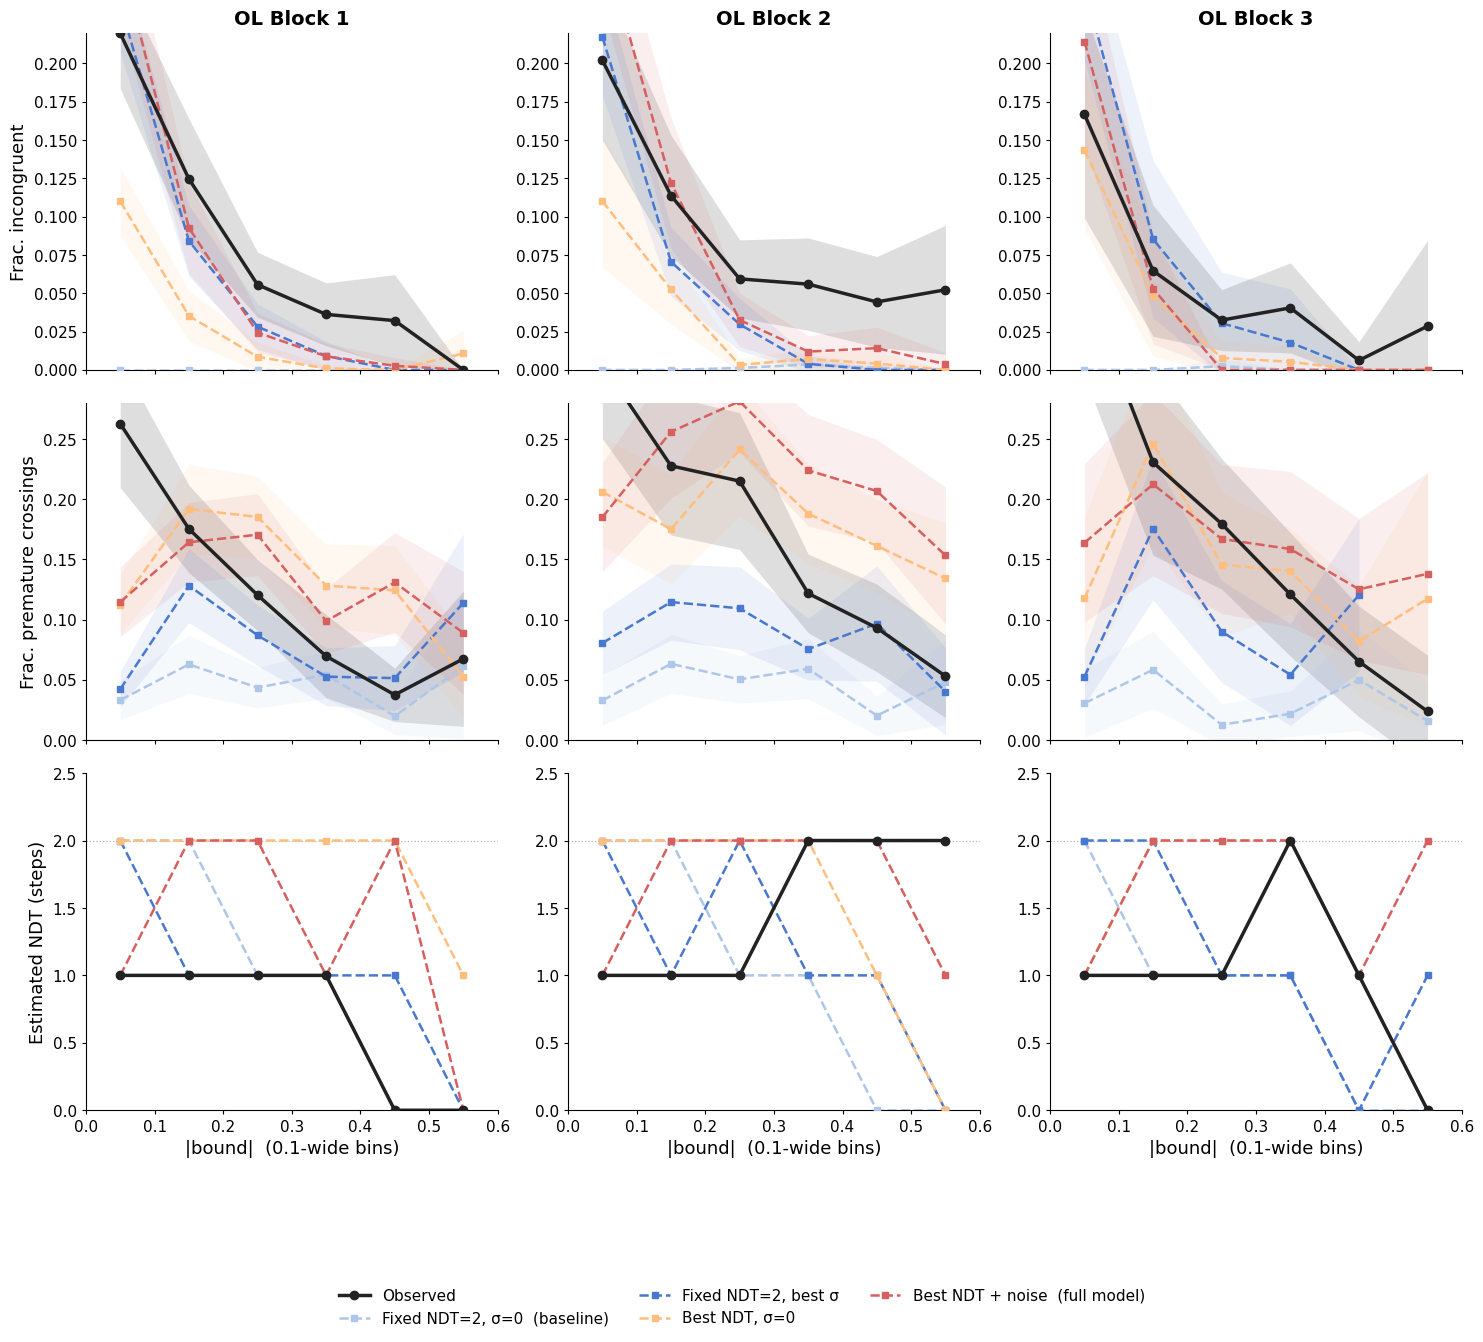

In [7]:
# ── Compute per-|bound|-bin statistics for all scenarios ─────────────────────
sim_bstats = {}
sim_bndt   = {}
for label in SCENARIOS:
    sim_bstats[label] = {}
    sim_bndt[label]   = {}
    for block in BLOCK_LIST:
        bd = (sim_trials[label][sim_trials[label]['block_index'] == block]
              .dropna(subset=['abs_bound']))
        sim_bstats[label][block] = {
            'incong': _binned_mean(bd, '_incong'),
            'early':  _binned_mean(bd, 'early_crossing_peak'),
        }
        sim_bndt[label][block] = _binned_ndt(
            bd['steps'].tolist(), bd['choice'].values, bd['abs_bound'].values
        )

# ── Formatted figure ──────────────────────────────────────────────────────────
SCENARIO_LABELS = {
    'Fixed NDT=2, no noise':   'Fixed NDT=2, σ=0  (baseline)',
    'Fixed NDT=2, best noise': 'Fixed NDT=2, best σ',
    'Best NDT, no noise':      'Best NDT, σ=0',
    'Best NDT + noise':        'Best NDT + noise  (full model)',
}

METRICS = [
    ('incong', 'Frac. incongruent',         (0.0, 0.22)),
    ('early',  'Frac. premature crossings',  (0.0, 0.28)),
    ('ndt',    'Estimated NDT (steps)',      (0.0, 2.5)),
]

fig, axes = plt.subplots(
    len(METRICS), len(BLOCK_LIST),
    figsize=(5.0 * len(BLOCK_LIST), 4.2 * len(METRICS)),
)

for ri, (metric, ylabel, ylim) in enumerate(METRICS):
    for bi, block in enumerate(BLOCK_LIST):
        ax = axes[ri, bi]

        # Observed — solid line + 95% CI ribbon
        if metric != 'ndt':
            cx, cy, cs = obs_bstats[block][metric]
            if len(cx):
                ax.plot(cx, cy, 'o-', color=PALETTE[0], lw=2.5, ms=6,
                        label='Observed', zorder=5)
                ax.fill_between(cx, cy - 1.96*cs, cy + 1.96*cs,
                                color=PALETTE[0], alpha=0.15, lw=0)
        else:
            cx, cy = obs_bndt[block]
            if len(cx):
                ax.plot(cx, cy, 'o-', color=PALETTE[0], lw=2.5, ms=6,
                        label='Observed', zorder=5)
            ax.axhline(2, color='gray', lw=0.9, ls=':', alpha=0.6)

        # Simulation scenarios — dashed lines + 95% CI ribbons
        for li, label in enumerate(SCENARIOS):
            color = PALETTE[li + 1]
            slab  = SCENARIO_LABELS[label]
            if metric != 'ndt':
                cx, cy, cs = sim_bstats[label][block][metric]
                if len(cx):
                    ax.plot(cx, cy, 's--', color=color, lw=1.8, ms=4,
                            label=slab, zorder=4)
                    ax.fill_between(cx, cy - 1.96*cs, cy + 1.96*cs,
                                    color=color, alpha=0.10, lw=0)
            else:
                cx, cy = sim_bndt[label][block]
                if len(cx):
                    ax.plot(cx, cy, 's--', color=color, lw=1.8, ms=4,
                            label=slab, zorder=4)

        ax.set_xlim(BIN_EDGES[0], BIN_EDGES[-1])
        ax.set_ylim(*ylim)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(length=3)

        if ri == 0:
            ax.set_title(f'OL Block {block}', fontweight='bold')
        if bi == 0:
            ax.set_ylabel(ylabel)
        if ri < len(METRICS) - 1:
            ax.set_xticklabels([])
        else:
            ax.set_xlabel('|bound|  (0.1-wide bins)')

handles, lbls = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, lbls, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.07), frameon=False)
plt.tight_layout(rect=[0, 0.06, 1, 1])

out = FIGURES_DIR / 'Figure03_S02.pdf'
fig.savefig(out, dpi=300, bbox_inches='tight')
print(f"Saved → {out}")
plt.show()